9_Meningitis_Dataset

¿Quién lo creó y cómo se obtuvieron los datos?
Este dataset, disponible en Kaggle bajo el usuario "chantest", reúne registros clínicos de pacientes diagnosticados con meningitis. Los datos fueron recolectados en contextos hospitalarios reales, a partir de la historia clínica de pacientes que ingresaron con sospecha de meningitis y fueron sometidos a análisis de sangre y punción lumbar para el análisis del líquido cefalorraquídeo (LCR). La meningitis es una inflamación de las meninges (membranas que protegen el cerebro y la médula espinal), y puede ser causada por bacterias, virus, hongos u otros agentes. Los métodos diagnósticos convencionales actualmente disponibles incluyen la punción lumbar para la recolección de LCR, el análisis por reacción en cadena de la polimerasa (PCR), los cultivos de sangre y las modalidades de imagen. El dataset tiene deliberadamente valores faltantes para practicar técnicas de imputación, lo que lo convierte en un recurso pedagógico especialmente valioso.

¿De qué trata?
Contiene registros clínicos y de laboratorio de pacientes con meningitis, cuyo propósito principal es permitir la diferenciación entre meningitis bacteriana y viral, que es uno de los problemas diagnósticos más urgentes en medicina de urgencias. La diferenciación entre meningitis bacteriana y viral es crucial: el fallo en administrar la terapia antibiótica adecuada en la meningitis bacteriana puede llevar a secuelas graves y permanentes, e incluso a la muerte.

¿Qué contiene?
El dataset incluye variables clínicas y de laboratorio típicas del diagnóstico de meningitis, entre ellas: edad del paciente, sexo, temperatura corporal, rigidez de nuca, fiebre, cefalea, nivel de glucosa en sangre, relación LCR/glucosa, nivel de proteínas en LCR, recuento de leucocitos en LCR, recuento de neutrófilos y linfocitos, proteína C reactiva (CRP), resultado de cultivo bacteriano, tipo de meningitis (bacteriana, viral, fúngica) y en algunos casos el resultado clínico del paciente. El elemento pedagógico central es que el dataset contiene valores faltantes de forma intencionada en múltiples variables clínicas, reflejo de la realidad hospitalaria donde no siempre se realizan todos los exámenes.

Objetivo del modelo
Clasificación: predecir el tipo de meningitis (principalmente bacteriana vs. viral) a partir de síntomas clínicos y resultados de laboratorio disponibles, incluso cuando algunos datos faltan. Antes de modelar, se debe practicar la imputación de valores faltantes (con media, mediana, moda, KNN imputer o imputación múltiple). Variables clave para la clasificación incluyen el recuento de leucocitos en LCR, niveles de glucosa, lactato, proteínas y resultados de la tinción de Gram del LCR. Este dataset es ideal para practicar pipelines con SimpleImputer o IterativeImputer de scikit-learn antes del modelo clasificador.

In [1]:
# ============================================================
# LIBRERÍAS GENERALES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

In [2]:
# ── PASO 1: CARGA ───────────────────────────────────────────
df_men = pd.read_csv('Datasets/9_Meningitis_Dataset/mening missing 12.csv')

print('Shape:', df_men.shape)
print('Columnas:', list(df_men.columns))
print('\nNulos por columna:')
print(df_men.isnull().sum())

Shape: (1200, 14)
Columnas: ['Patient_ID', 'Age', 'Gender', 'WBC_Count', 'Protein_Level', 'Glucose_Level', 'Pathogen_Present', 'Diagnosis', 'Outcome', 'Hemoglobin', 'WBC_Blood_Count', 'Platelets', 'CRP_Level', 'Risk_Level']

Nulos por columna:
Patient_ID           0
Age                  7
Gender               9
WBC_Count            8
Protein_Level       10
Glucose_Level        8
Pathogen_Present     8
Diagnosis           12
Outcome             10
Hemoglobin          19
WBC_Blood_Count     10
Platelets           12
CRP_Level           13
Risk_Level           0
dtype: int64


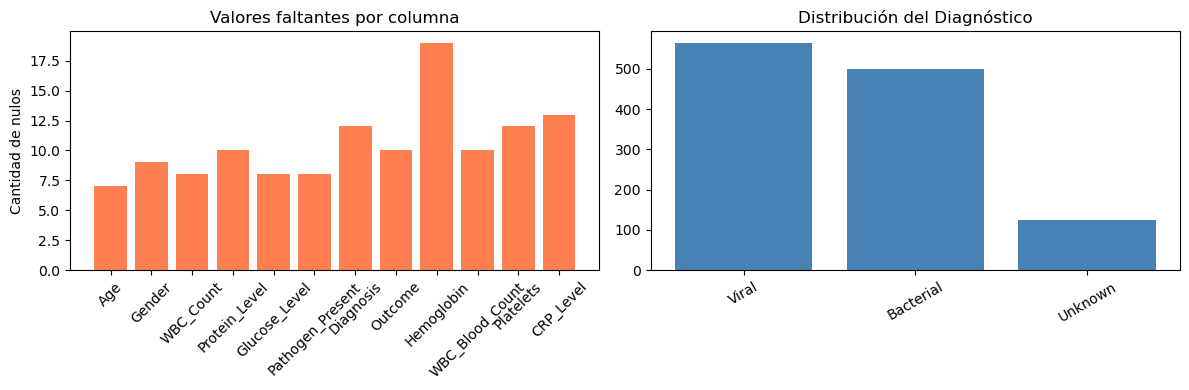

In [3]:
# ── PASO 2: GRAFICAR NULOS y DIAGNÓSTICO ────────────────────
nulos_men = df_men.isnull().sum()
nulos_men = nulos_men[nulos_men > 0]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.bar(range(len(nulos_men)), nulos_men.values, color='coral')
plt.xticks(range(len(nulos_men)), nulos_men.index, rotation=45)
plt.title('Valores faltantes por columna')
plt.ylabel('Cantidad de nulos')

plt.subplot(1, 2, 2)
diag_counts = df_men['Diagnosis'].value_counts()
plt.bar(range(len(diag_counts)), diag_counts.values, color='steelblue')
plt.xticks(range(len(diag_counts)), diag_counts.index, rotation=30)
plt.title('Distribución del Diagnóstico')
plt.tight_layout()
plt.show()

In [4]:
# ── PASO 3: LIMPIEZA — IMPUTACIÓN DE NULOS ──────────────────
# Columnas numéricas: reemplazar nulos con la MEDIANA
cols_num_men = ['Age','WBC_Count','Protein_Level','Glucose_Level',
                'Hemoglobin','WBC_Blood_Count','Platelets','CRP_Level']
for col in cols_num_men:
    mediana = df_men[col].median()
    df_men[col] = df_men[col].fillna(mediana)
    print(f'  {col}: imputado con mediana = {mediana:.2f}')

# Columnas de texto: reemplazar nulos con la MODA (valor más frecuente)
cols_txt_men = ['Gender','Pathogen_Present','Diagnosis','Outcome']
for col in cols_txt_men:
    moda = df_men[col].mode()[0]
    df_men[col] = df_men[col].fillna(moda)
    print(f'  {col}: imputado con moda = {moda}')

print('\nNulos restantes:', df_men.isnull().sum().sum())

  Age: imputado con mediana = 43.00
  WBC_Count: imputado con mediana = 12282.00
  Protein_Level: imputado con mediana = 108.00
  Glucose_Level: imputado con mediana = 53.00
  Hemoglobin: imputado con mediana = 12.00
  WBC_Blood_Count: imputado con mediana = 9782.50
  Platelets: imputado con mediana = 161890.50
  CRP_Level: imputado con mediana = 25.00
  Gender: imputado con moda = Male
  Pathogen_Present: imputado con moda = No
  Diagnosis: imputado con moda = Viral
  Outcome: imputado con moda = Recovered

Nulos restantes: 0


In [5]:
# ── PASO 4: CONVERTIR TEXTO A NÚMEROS ───────────────────────
# Target: Diagnosis → código numérico (0, 1, 2, 3...)
df_men['Gender_num']   = pd.Categorical(df_men['Gender']).codes.astype(float)
df_men['Pathogen_num'] = pd.Categorical(df_men['Pathogen_Present']).codes.astype(float)
df_men['Diagnosis_num']= pd.Categorical(df_men['Diagnosis']).codes

# Mostrar mapeo del diagnóstico
print('Mapeo de diagnóstico:')
for codigo, nombre in enumerate(pd.Categorical(df_men['Diagnosis']).categories):
    print(f'  {codigo} = {nombre}')

y_men = df_men['Diagnosis_num'].values.astype(float)

Mapeo de diagnóstico:
  0 = Bacterial
  1 = Unknown
  2 = Viral


In [6]:
# ── PASO 5: CONSTRUIR X ─────────────────────────────────────
cols_feat_men = ['Age','Gender_num','WBC_Count','Protein_Level',
                 'Glucose_Level','Pathogen_num','Hemoglobin',
                 'WBC_Blood_Count','Platelets','CRP_Level']

X_raw_men = df_men[cols_feat_men].values.astype(float)
m_men = y_men.size

print('X shape:', X_raw_men.shape)
print('Clases de diagnóstico:', np.unique(y_men))
print('Nulos en X:', np.isnan(X_raw_men).sum())

X shape: (1200, 10)
Clases de diagnóstico: [0. 1. 2.]
Nulos en X: 0


In [7]:
# ============================================================
# FUNCIÓN DE BALANCEO — oversampling con numpy
# ============================================================
def balancear(X, y):
    """
    Balancea un dataset desbalanceado usando OVERSAMPLING.
    
    ¿Qué hace?
    - Identifica cuántos ejemplos tiene cada clase
    - La clase con MÁS ejemplos queda igual
    - Las clases con MENOS ejemplos se repiten (con reemplazo)
      hasta tener la misma cantidad que la clase mayoritaria
    - Al final todas las clases tienen el mismo número de filas
    
    ¿Por qué oversampling y no undersampling?
    - Undersampling borra filas → perdemos información
    - Oversampling agrega filas → mantenemos toda la información original
    """
    clases = np.unique(y)
    n_max  = max(np.sum(y == c) for c in clases)   # tamaño de la clase más grande
    
    X_bal_list = []
    y_bal_list = []
    
    for c in clases:
        idx    = np.where(y == c)[0]               # índices de esta clase
        n_c    = len(idx)                           # cuántos ejemplos tiene
        
        if n_c < n_max:
            # repetir filas hasta alcanzar n_max
            extra  = n_max - n_c
            idx_extra = np.random.choice(idx, size=extra, replace=True)
            idx_final = np.concatenate([idx, idx_extra])
        else:
            idx_final = idx
        
        X_bal_list.append(X[idx_final])
        y_bal_list.append(y[idx_final])
    
    X_bal = np.concatenate(X_bal_list, axis=0)
    y_bal = np.concatenate(y_bal_list, axis=0)
    
    # Mezclar aleatoriamente para no dejar todas las clases juntas
    perm  = np.random.permutation(len(y_bal))
    return X_bal[perm], y_bal[perm]

def mostrar_balance(y, nombre, antes_despues='ANTES'):
    """Imprime cuántos ejemplos tiene cada clase."""
    clases, cuentas = np.unique(y, return_counts=True)
    print(f'  Balance {antes_despues} — {nombre}:')
    for c, n in zip(clases, cuentas):
        print(f'    Clase {int(c)}: {n} ({n/len(y)*100:.1f}%)')

np.random.seed(42)   # para reproducibilidad
print('Funciones de balanceo definidas')

Funciones de balanceo definidas


In [8]:
# ── BALANCEO ─────────────────────────────────
mostrar_balance(y_men, 'Meningitis', 'ANTES')

  Balance ANTES — Meningitis:
    Clase 0: 499 (41.6%)
    Clase 1: 124 (10.3%)
    Clase 2: 577 (48.1%)


In [9]:
def featureNormalize(X):
    """
    Normaliza las features de X.
    Para cada columna: resta la media y divide por la desviación estándar.
    
    Retorna:
      X_norm : X normalizado (mismo tamaño que X)
      mu     : media de cada columna (se guarda para normalizar datos nuevos)
      sigma  : desviación estándar de cada columna
    """
    X_norm = X.copy()
    mu     = np.mean(X, axis=0)   # media de cada columna
    sigma  = np.std(X, axis=0)    # desviación estándar de cada columna
    X_norm = (X - mu) / sigma     # estandarización Z-score
    return X_norm, mu, sigma

In [10]:
# ── PASO 6: NORMALIZAR y COLUMNA DE UNOS ────────────────────
X_norm_men, mu_men, sigma_men = featureNormalize(X_raw_men)
X_bal_men, y_bal_men = balancear(X_norm_men, y_men)

mostrar_balance(y_bal_men, 'Meningitis', 'DESPUÉS')

X_men = np.concatenate([np.ones((len(y_bal_men), 1)), X_bal_men], axis=1)
y_men  = y_bal_men

print('X_men final:', X_men.shape)
print('X:', X_men.shape, '| y:', y_men.shape)

  Balance DESPUÉS — Meningitis:
    Clase 0: 577 (33.3%)
    Clase 1: 577 (33.3%)
    Clase 2: 577 (33.3%)
X_men final: (1731, 11)
X: (1731, 11) | y: (1731,)
